# 0.3 — Generación de números aleatorios

## Motivación

Todo estimador Monte Carlo descansa, en última instancia, sobre un generador de números pseudoaleatorios (PRNG) y sobre las transformaciones que convierten uniformes en las distribuciones que necesitamos: normales para difusiones, exponenciales para tiempos de default o de llegada, Beta para tasas de recuperación, vectores correlacionados para canastas de activos. Si el PRNG tiene estructura oculta (como el tristemente célebre RANDU) o si la transformación uniforme→objetivo está mal implementada, el sesgo se propaga silenciosamente a cada precio, cada griega y cada VaR que se calcule encima.

Este notebook cubre las piezas de base de toda la simulación del currículum: (i) qué hace a un PRNG "bueno" y por qué los LCG clásicos fallan; (ii) el método de la transformada inversa, la herramienta más general para pasar de $U(0,1)$ a cualquier distribución con CDF invertible; (iii) Box-Muller, el método clásico para generar normales; (iv) aceptación-rechazo, para distribuciones sin inversa cerrada; y (v) la factorización de Cholesky, que permite generar vectores gaussianos correlacionados — la base de toda simulación multiactivo (Módulo 05 en adelante).

## 1. Generadores de números pseudoaleatorios

### 1.1 ¿Qué es un PRNG?

Un generador de números pseudoaleatorios es una función determinista $x_{n+1} = T(x_n)$ que, partiendo de un estado inicial (la *semilla*), produce una secuencia $(x_n)$ que **parece** una muestra i.i.d. de $U(0,1)$ bajo cualquier batería de tests estadísticos razonable, aunque sea perfectamente reproducible y periódica. Lo que separa un buen PRNG de uno malo es: (a) período astronómicamente largo, (b) ausencia de correlación entre valores consecutivos (o entre $k$-tuplas consecutivas), y (c) equidistribución en dimensiones altas.

### 1.2 Generadores congruenciales lineales (LCG) y su falla clásica

Un **LCG** genera la secuencia
$$
x_{n+1} = (a\, x_n + c) \bmod m,
$$
con parámetros enteros $a$ (multiplicador), $c$ (incremento) y $m$ (módulo); el número uniforme es $u_n = x_n / m$. Son triviales de implementar y extremadamente rápidos, pero **cualquier LCG tiene estructura reticular**: las $k$-tuplas consecutivas $(u_n, u_{n+1}, \dots, u_{n+k-1})$ caen, con probabilidad 1, sobre un número finito de hiperplanos paralelos en $[0,1]^k$ (teorema de Marsaglia, 1968) — no llenan el hipercubo de manera uniforme, sin importar cuántos puntos se generen.

El caso histórico más famoso es **RANDU**, usado en librerías científicas de IBM en los años 60-70:
$$
x_{n+1} = 65539\, x_n \bmod 2^{31}, \qquad c = 0.
$$
Como $65539 = 2^{16} + 3$, se puede mostrar algebraicamente que $x_{n+2} \equiv 6\, x_{n+1} - 9\, x_n \pmod{2^{31}}$, una relación lineal exacta entre tres valores consecutivos. Esto implica que **todas** las triadas $(u_n, u_{n+1}, u_{n+2})$ caen sobre solo **15 planos** en el cubo unitario $[0,1]^3$ — visible a simple vista en un scatter 3D (Demo 1). RANDU se usó durante años en simulaciones que asumían independencia en 3D, con resultados sesgados sin que nadie lo notara hasta que Marsaglia publicó el análisis.

### 1.3 Generadores modernos: PCG64

`numpy.random.default_rng()` usa por defecto **PCG64** (Permuted Congruential Generator), que combina un LCG interno de 128 bits con una permutación no lineal de la salida. La permutación destruye la estructura lineal que hace fallar a los LCG puros: PCG64 pasa las baterías de tests TestU01 BigCrush y tiene período $2^{128}$, muy por encima de cualquier volumen de simulación práctico en finanzas cuantitativas. Es el generador que usamos en **todo** el resto del currículum vía `rng = np.random.default_rng(seed)`.

## 2. Método de la transformada inversa

**Proposición.** Sea $F$ la CDF de una distribución objetivo, continua y estrictamente creciente en su soporte, con inversa $F^{-1}$. Si $U \sim \text{Uniform}(0,1)$, entonces
$$
X = F^{-1}(U)
$$
tiene CDF exactamente $F$.

*Demostración.* Para cualquier $x$ en el soporte,
$$
\mathbb{P}(X \leq x) = \mathbb{P}\big(F^{-1}(U) \leq x\big) = \mathbb{P}\big(U \leq F(x)\big) = F(x),
$$
donde el segundo paso usa que $F$ es estrictamente creciente (así $F^{-1}(U) \leq x \iff U \leq F(x)$), y el tercero usa que $U \sim \text{Uniform}(0,1)$ implica $\mathbb{P}(U \leq u) = u$ para $u \in [0,1]$. Como esto vale para todo $x$, $X$ tiene CDF $F$. $\blacksquare$

**Caso Exponencial($\lambda$).** La CDF es $F(x) = 1 - e^{-\lambda x}$ para $x \geq 0$. Despejando $u = 1 - e^{-\lambda x}$:
$$
x = F^{-1}(u) = -\frac{\ln(1-u)}{\lambda}.
$$
Como $U$ y $1-U$ tienen la misma distribución $\text{Uniform}(0,1)$, en la práctica se usa la forma equivalente y numéricamente más simple
$$
X = -\frac{\ln U}{\lambda}.
$$
La Demo 2 usa exactamente esta transformación para $\lambda = 2$.

## 3. Box-Muller

La exponencial tiene inversa cerrada, pero la normal estándar no: $\Phi^{-1}$ no tiene forma analítica simple. Box y Muller (1958) resolvieron esto no invirtiendo $\Phi$ directamente, sino trabajando con **dos** normales a la vez en coordenadas polares.

**Derivación.** Sean $Z_1, Z_2$ independientes $N(0,1)$, con densidad conjunta
$$
f(z_1, z_2) = \frac{1}{2\pi} \exp\!\left(-\frac{z_1^2 + z_2^2}{2}\right), \qquad (z_1, z_2) \in \mathbb{R}^2.
$$
Cambiamos a coordenadas polares $z_1 = r\cos\theta$, $z_2 = r\sin\theta$, con jacobiano $r$. La densidad conjunta de $(R, \Theta)$ es
$$
f(r,\theta) = \frac{1}{2\pi} e^{-r^2/2} \cdot r = \underbrace{r\, e^{-r^2/2}}_{f_R(r)} \cdot \underbrace{\frac{1}{2\pi}}_{f_\Theta(\theta)}, \qquad r \geq 0,\ \theta \in [0, 2\pi).
$$
La densidad conjunta **factoriza** en un producto de una densidad en $r$ y una densidad en $\theta$, así que $R$ y $\Theta$ son independientes: $\Theta \sim \text{Uniform}(0, 2\pi)$, y $R$ tiene densidad de Rayleigh $f_R(r) = r e^{-r^2/2}$ con CDF $F_R(r) = 1 - e^{-r^2/2}$.

Ambos factores son fáciles de simular: $\Theta$ es uniforme directa, y $R$ se obtiene por transformada inversa (Sección 2) aplicada a $F_R$: si $U_1 \sim \text{Uniform}(0,1)$, entonces $R = \sqrt{-2\ln U_1}$ tiene la CDF correcta. Combinando con $U_2 \sim \text{Uniform}(0,1)$ independiente para $\Theta = 2\pi U_2$, y deshaciendo el cambio de coordenadas:
$$
Z_1 = \sqrt{-2\ln U_1}\, \cos(2\pi U_2), \qquad Z_2 = \sqrt{-2\ln U_1}\, \sin(2\pi U_2)
$$
son dos normales estándar **independientes**. Este es el método de Box-Muller "trigonométrico" — la Demo 3 lo implementa directamente. (Existe una variante, el **método polar de Marsaglia**, que evita senos y cosenos muestreando $(V_1, V_2)$ uniformes en el disco unitario por aceptación-rechazo y reescalando; es más rápida en CPUs sin instrucciones trigonométricas dedicadas, pero produce la misma distribución objetivo.)

## 4. Aceptación-rechazo

Cuando ni la CDF objetivo ni una transformación cerrada están disponibles (caso típico de la Beta, la Gamma con parámetros no enteros, colas truncadas, etc.), el método de **aceptación-rechazo** permite muestrear de una densidad objetivo $f$ usando solo una densidad **propuesta** $g$ de la que sí sabemos muestrear, siempre que exista una constante $M \geq 1$ con
$$
f(x) \leq M\, g(x) \qquad \forall x.
$$

**Algoritmo.** Repetir: muestrear $X \sim g$ y $U \sim \text{Uniform}(0,1)$ independientes; aceptar $X$ si
$$
U \leq \frac{f(X)}{M\, g(X)},
$$
en caso contrario rechazar y repetir.

**Proposición (la distribución aceptada es $f$, y la probabilidad de aceptación es $1/M$).**

*Demostración.* Sea $A$ el evento de aceptación en una iteración. Por la ley de la esperanza total sobre $X \sim g$,
$$
\mathbb{P}(A) = \mathbb{E}_g\!\left[\mathbb{P}\!\left(U \leq \frac{f(X)}{M g(X)} \,\middle|\, X\right)\right] = \mathbb{E}_g\!\left[\frac{f(X)}{M g(X)}\right] = \int \frac{f(x)}{M g(x)}\, g(x)\, dx = \frac{1}{M}\int f(x)\, dx = \frac{1}{M},
$$
usando que $\int f = 1$. Además, la densidad condicional del valor aceptado es
$$
f_{X \mid A}(x) = \frac{g(x)\, \mathbb{P}(A \mid X=x)}{\mathbb{P}(A)} = \frac{g(x) \cdot f(x)/(M g(x))}{1/M} = f(x),
$$
es decir, condicionado a aceptar, $X$ tiene exactamente la densidad objetivo $f$. $\blacksquare$

Cuanto más ajustada sea la envolvente ($M$ más cercano a 1), mayor la tasa de aceptación $1/M$ y menos muestras se desperdician.

**Caso Beta(2,5) con envolvente uniforme.** La densidad objetivo es $f(x) = 30\, x (1-x)^4$ en $[0,1]$ (con $B(2,5) = \frac{1! \, 4!}{6!} = \frac{1}{30}$), y usamos la envolvente más simple posible, $g(x) = \mathbb{1}_{[0,1]}(x)$ (uniforme). Necesitamos $M = \max_{x \in [0,1]} f(x)$. Derivando,
$$
f'(x) = 30\big[(1-x)^4 - 4x(1-x)^3\big] = 30(1-x)^3(1 - 5x),
$$
que se anula en $x = 1/5$ (el modo). Evaluando,
$$
M = f(1/5) = 30 \cdot \frac{1}{5}\left(\frac{4}{5}\right)^4 = 2.4576,
$$
y la tasa de aceptación teórica es $1/M \approx 0.4069$ — la Demo 4 la contrasta contra la tasa empírica.

## 5. Normales correlacionadas vía factorización de Cholesky

Simular activos correlacionados (canastas, cestas de crédito, curvas) requiere generar vectores gaussianos con una matriz de covarianza objetivo $\Sigma$, no componentes independientes.

**Proposición (factorización de Cholesky).** Toda matriz $\Sigma \in \mathbb{R}^{d \times d}$ simétrica y definida positiva admite una única factorización
$$
\Sigma = L L^{\mathsf{T}},
$$
con $L$ triangular inferior de entradas diagonales estrictamente positivas.

*Construcción (por inducción / sustitución hacia adelante).* Igualando entrada a entrada $(\Sigma)_{ij} = \sum_{k=1}^{\min(i,j)} L_{ik} L_{jk}$ y resolviendo columna por columna:
$$
L_{jj} = \sqrt{\Sigma_{jj} - \sum_{k=1}^{j-1} L_{jk}^2}, \qquad L_{ij} = \frac{1}{L_{jj}}\left(\Sigma_{ij} - \sum_{k=1}^{j-1} L_{ik} L_{jk}\right) \quad (i > j).
$$
Cada $L_{jj}$ está bien definido y es positivo porque la definición positiva de $\Sigma$ garantiza que el término bajo la raíz es siempre $> 0$ en cada paso (es el complemento de Schur del bloque ya factorizado).

**Uso para simulación.** Sea $Z = (Z_1, \dots, Z_d)^{\mathsf{T}}$ con componentes i.i.d. $N(0,1)$, así $\text{Cov}(Z) = I_d$. Definimos $X = L Z$. Entonces
$$
\text{Cov}(X) = \mathbb{E}[X X^{\mathsf{T}}] = \mathbb{E}[L Z Z^{\mathsf{T}} L^{\mathsf{T}}] = L\, \mathbb{E}[Z Z^{\mathsf{T}}]\, L^{\mathsf{T}} = L\, I_d\, L^{\mathsf{T}} = L L^{\mathsf{T}} = \Sigma,
$$
y $X$ es gaussiano (combinación lineal de gaussianas) con media $0$, luego $X \sim N(0, \Sigma)$. La Demo 5 aplica esto a una $\Sigma$ de $3\times 3$ con correlaciones objetivo $0.6$, $0.3$ y $0.1$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3d projection)
from scipy import stats

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## Demo 1 — RANDU (LCG malo) vs PCG64: estructura en 3D

Generamos $n$ triadas consecutivas $(u_i, u_{i+1}, u_{i+2})$ con el LCG de RANDU ($a=65539$, $m=2^{31}$, $c=0$) y las comparamos, en el mismo cubo $[0,1]^3$, contra triadas generadas con PCG64 (`rng.random`). RANDU debería mostrar sus 15 planos característicos; PCG64 debería llenar el cubo sin estructura visible.

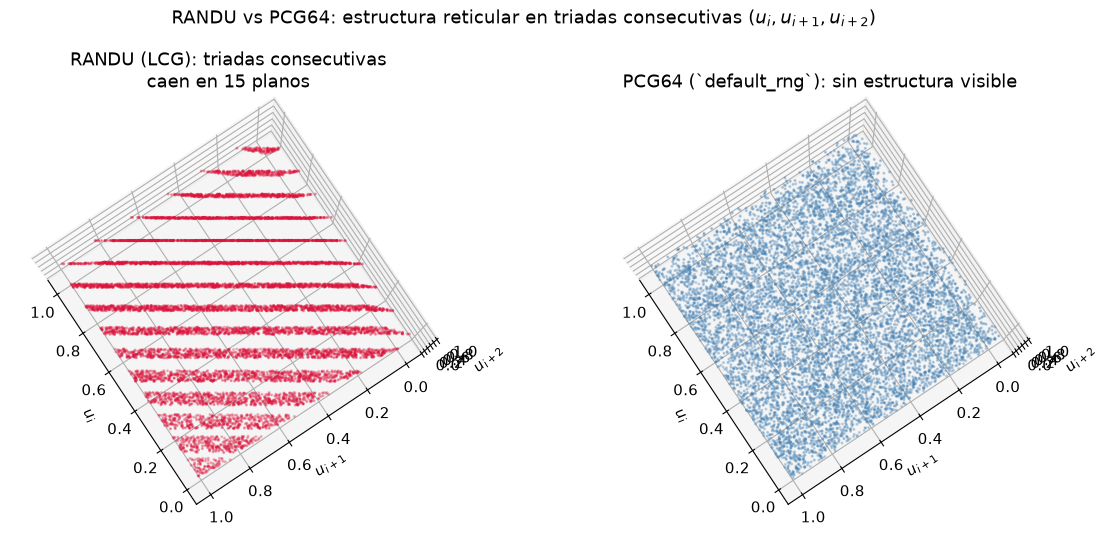

In [2]:
def randu_lcg(seed: int, n: int) -> np.ndarray:
    """RANDU: x_{n+1} = 65539 * x_n mod 2**31, c=0. Returns n uniforms in (0,1)."""
    a, m = 65539, 2**31
    x = seed
    out = np.empty(n, dtype=np.float64)
    for i in range(n):
        x = (a * x) % m
        out[i] = x / m
    return out

n_triples = 10_000
randu_seed = 1  # must be odd, nonzero

u_randu = randu_lcg(randu_seed, n_triples * 3 + 2)
randu_triples = np.stack([u_randu[0:n_triples], u_randu[1:n_triples + 1], u_randu[2:n_triples + 2]], axis=1)

u_pcg = rng.random(n_triples * 3 + 2)
pcg_triples = np.stack([u_pcg[0:n_triples], u_pcg[1:n_triples + 1], u_pcg[2:n_triples + 2]], axis=1)

fig = plt.figure(figsize=(12, 5.5))

# Viewing angle chosen so the camera looks almost along the plane normal
# (9, -6, 1) of the exact relation u_{i+2} = 6 u_{i+1} - 9 u_i (mod 1),
# which makes RANDU's 15 hyperplanes collapse visually into parallel stripes.
randu_elev, randu_azim = 84.7, 146.3

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(randu_triples[:, 0], randu_triples[:, 1], randu_triples[:, 2], s=1.5, alpha=0.6, color="crimson")
ax1.view_init(elev=randu_elev, azim=randu_azim)
ax1.set_xlabel("$u_i$")
ax1.set_ylabel("$u_{i+1}$")
ax1.set_zlabel("$u_{i+2}$")
ax1.set_title("RANDU (LCG): triadas consecutivas\ncaen en 15 planos")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(pcg_triples[:, 0], pcg_triples[:, 1], pcg_triples[:, 2], s=1.5, alpha=0.6, color="steelblue")
ax2.view_init(elev=randu_elev, azim=randu_azim)
ax2.set_xlabel("$u_i$")
ax2.set_ylabel("$u_{i+1}$")
ax2.set_zlabel("$u_{i+2}$")
ax2.set_title("PCG64 (`default_rng`): sin estructura visible")

fig.suptitle("RANDU vs PCG64: estructura reticular en triadas consecutivas $(u_i, u_{i+1}, u_{i+2})$")
fig.tight_layout()
plt.show()

En el panel izquierdo, girando el cubo hacia el ángulo correcto (el usado aquí), las triadas de RANDU se alinean visiblemente sobre planos paralelos — consecuencia directa de la relación lineal exacta $x_{n+2} \equiv 6x_{n+1} - 9x_n \pmod{2^{31}}$ derivada en la Sección 1.2. El panel derecho, con PCG64, no muestra ningún patrón: las triadas llenan el cubo de manera aparentemente uniforme, como se espera de un generador moderno.

## Demo 2 — Transformada inversa: Exponencial($\lambda=2$)

Generamos $U \sim \text{Uniform}(0,1)$ con PCG64 y aplicamos $X = -\ln(U)/\lambda$ (Sección 2). Comparamos el histograma resultante contra la densidad teórica $f(x) = \lambda e^{-\lambda x}$.

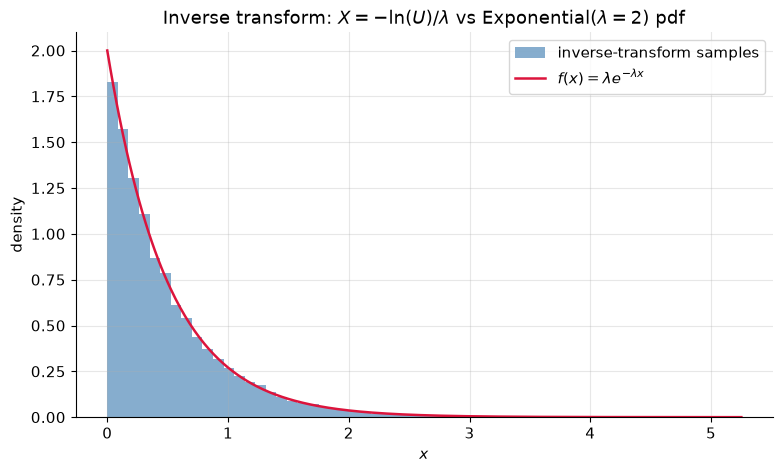

In [3]:
lam = 2.0
n_exp = 20_000

u_exp = rng.random(n_exp)
x_exp = -np.log(u_exp) / lam

x_grid = np.linspace(0, x_exp.max(), 400)
pdf_exp = lam * np.exp(-lam * x_grid)

fig, ax = plt.subplots()
ax.hist(x_exp, bins=60, density=True, color="steelblue", alpha=0.65, label="inverse-transform samples")
ax.plot(x_grid, pdf_exp, color="crimson", linewidth=1.8, label=r"$f(x)=\lambda e^{-\lambda x}$")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.set_title(r"Inverse transform: $X=-\ln(U)/\lambda$ vs Exponential($\lambda=2$) pdf")
ax.legend()
plt.show()

El histograma de las $n=20\,000$ muestras generadas por transformada inversa sigue de cerca la densidad exponencial teórica en todo el rango, incluida la cola — exactamente lo que predice la Proposición de la Sección 2, sin necesidad de ningún ajuste adicional.

## Demo 3 — Box-Muller: scatter conjunto y marginales

Aplicamos las fórmulas de la Sección 3, $Z_1 = \sqrt{-2\ln U_1}\cos(2\pi U_2)$, $Z_2 = \sqrt{-2\ln U_1}\sin(2\pi U_2)$, y verificamos visualmente que $(Z_1, Z_2)$ es una nube gaussiana bivariada esférica (independencia + varianza unitaria) y que cada marginal es $N(0,1)$.

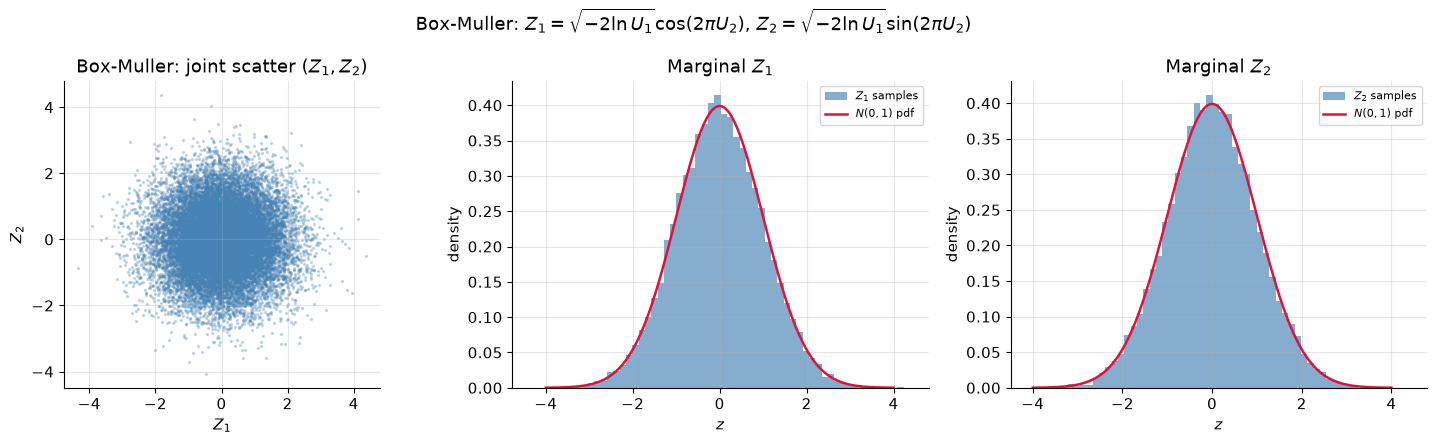

In [4]:
n_bm = 20_000

u1_bm = rng.random(n_bm)
u2_bm = rng.random(n_bm)
r_bm = np.sqrt(-2.0 * np.log(u1_bm))
theta_bm = 2.0 * np.pi * u2_bm
z1_bm = r_bm * np.cos(theta_bm)
z2_bm = r_bm * np.sin(theta_bm)

x_grid_n = np.linspace(-4, 4, 400)
normal_pdf = stats.norm.pdf(x_grid_n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(z1_bm, z2_bm, s=2, alpha=0.25, color="steelblue")
axes[0].set_xlabel("$Z_1$")
axes[0].set_ylabel("$Z_2$")
axes[0].set_title("Box-Muller: joint scatter $(Z_1, Z_2)$")
axes[0].set_aspect("equal")

axes[1].hist(z1_bm, bins=60, density=True, color="steelblue", alpha=0.65, label="$Z_1$ samples")
axes[1].plot(x_grid_n, normal_pdf, color="crimson", linewidth=1.8, label="$N(0,1)$ pdf")
axes[1].set_xlabel("$z$")
axes[1].set_ylabel("density")
axes[1].set_title("Marginal $Z_1$")
axes[1].legend(fontsize=8)

axes[2].hist(z2_bm, bins=60, density=True, color="steelblue", alpha=0.65, label="$Z_2$ samples")
axes[2].plot(x_grid_n, normal_pdf, color="crimson", linewidth=1.8, label="$N(0,1)$ pdf")
axes[2].set_xlabel("$z$")
axes[2].set_ylabel("density")
axes[2].set_title("Marginal $Z_2$")
axes[2].legend(fontsize=8)

fig.suptitle(r"Box-Muller: $Z_1=\sqrt{-2\ln U_1}\cos(2\pi U_2)$, $Z_2=\sqrt{-2\ln U_1}\sin(2\pi U_2)$")
fig.tight_layout()
plt.show()

El scatter conjunto (panel izquierdo) es una nube circularmente simétrica sin dependencia visible entre $Z_1$ y $Z_2$ — consistente con la independencia derivada en la Sección 3 a partir de la factorización de la densidad polar. Ambas marginales (paneles centro y derecha) se ajustan de cerca a la densidad $N(0,1)$ teórica.

## Demo 4 — Aceptación-rechazo: Beta(2,5) con envolvente uniforme

Usamos $g(x) = \mathbb{1}_{[0,1]}(x)$ y $M = 2.4576$ (Sección 4) para muestrear de $f(x) = 30\,x(1-x)^4$ por aceptación-rechazo, y comparamos la tasa de aceptación empírica contra la teórica $1/M$.

Proposals used        = 60000
Accepted (total)      = 24412
Kept for histogram    = 20000
Empirical accept rate = 0.4069
Theoretical 1/M       = 0.4069


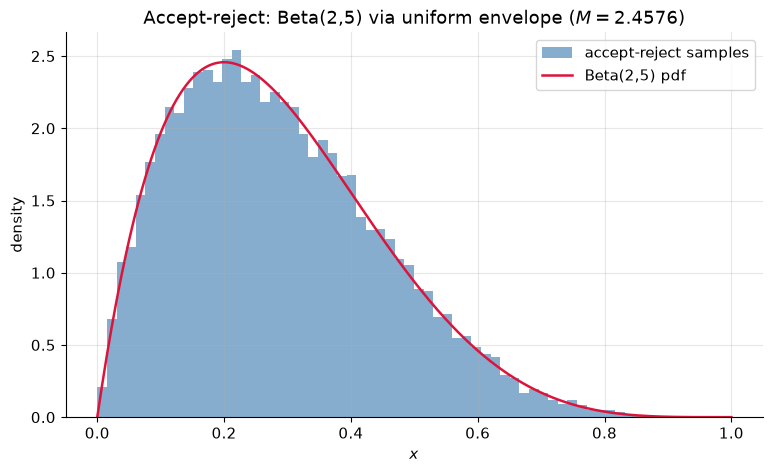

In [5]:
a_beta, b_beta = 2, 5
M_beta = 30.0 * 0.2 * 0.8**4  # f(1/5), the mode value
n_target = 20_000

accepted = []
n_accepted = 0
n_proposals = 0
batch = 30_000  # ~ n_target / (1/M) with margin, single batch keeps us well under 200k

while n_accepted < n_target:
    x_prop = rng.random(batch)
    u_prop = rng.random(batch)
    f_prop = 30.0 * x_prop * (1 - x_prop) ** 4
    accept_mask = u_prop <= f_prop / M_beta
    accepted.append(x_prop[accept_mask])
    n_accepted += int(accept_mask.sum())
    n_proposals += batch

x_beta = np.concatenate(accepted)[:n_target]
empirical_accept_rate = n_accepted / n_proposals
theoretical_accept_rate = 1.0 / M_beta

print(f"Proposals used        = {n_proposals}")
print(f"Accepted (total)      = {n_accepted}")
print(f"Kept for histogram    = {n_target}")
print(f"Empirical accept rate = {empirical_accept_rate:.4f}")
print(f"Theoretical 1/M       = {theoretical_accept_rate:.4f}")

x_grid_beta = np.linspace(0, 1, 400)
pdf_beta = stats.beta(a_beta, b_beta).pdf(x_grid_beta)

fig, ax = plt.subplots()
ax.hist(x_beta, bins=60, density=True, color="steelblue", alpha=0.65, label="accept-reject samples")
ax.plot(x_grid_beta, pdf_beta, color="crimson", linewidth=1.8, label="Beta(2,5) pdf")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.set_title(r"Accept-reject: Beta(2,5) via uniform envelope ($M=2.4576$)")
ax.legend()
plt.show()

La tasa de aceptación empírica reproduce la teórica $1/M \approx 0.4069$ dentro del ruido de simulación, y el histograma de las muestras aceptadas se superpone con la densidad Beta(2,5) objetivo — confirmando ambas partes de la Proposición de la Sección 4: la distribución condicional a aceptar es $f$, y la tasa de aceptación es $1/M$.

## Demo 5 — Normales correlacionadas 3D vía Cholesky

Objetivo: $\Sigma$ de $3\times 3$ con correlaciones $\rho_{12}=0.6$, $\rho_{13}=0.3$, $\rho_{23}=0.1$ (varianzas unitarias). Factorizamos $\Sigma = LL^{\mathsf{T}}$ con `np.linalg.cholesky`, generamos $Z \sim N(0, I_3)$ y formamos $X = LZ$; comparamos la correlación empírica contra $\Sigma$ en un heatmap.

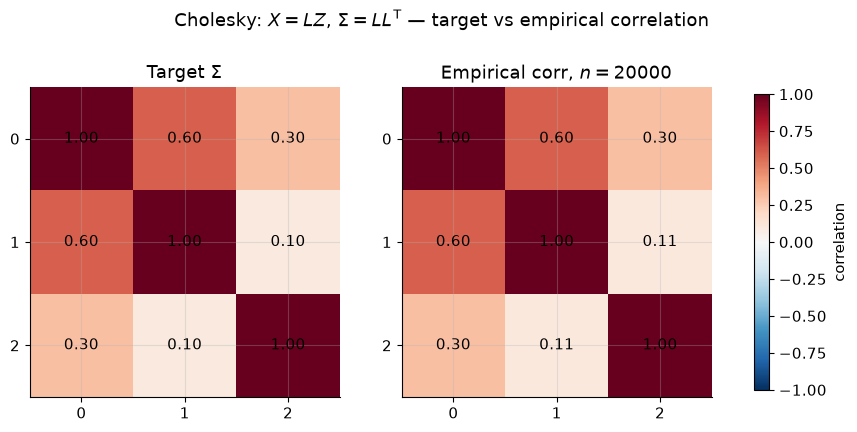

In [6]:
Sigma = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.1],
    [0.3, 0.1, 1.0],
])

L = np.linalg.cholesky(Sigma)

n_chol = 20_000
Z = rng.standard_normal(size=(n_chol, 3))
X = Z @ L.T  # each row is L @ z, so X has shape (n_chol, 3)

corr_empirical = np.corrcoef(X, rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

im0 = axes[0].imshow(Sigma, vmin=-1, vmax=1, cmap="RdBu_r")
axes[0].set_title(r"Target $\Sigma$")
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{Sigma[i, j]:.2f}", ha="center", va="center")

im1 = axes[1].imshow(corr_empirical, vmin=-1, vmax=1, cmap="RdBu_r")
axes[1].set_title(f"Empirical corr, $n={n_chol}$")
axes[1].set_xticks(range(3))
axes[1].set_yticks(range(3))
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, f"{corr_empirical[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im1, ax=axes.tolist(), shrink=0.8, label="correlation")
fig.suptitle(r"Cholesky: $X = LZ$, $\Sigma = LL^{\mathsf{T}}$ — target vs empirical correlation")
plt.show()

El heatmap de correlación empírica reproduce visualmente al de $\Sigma$: los tres coeficientes objetivo ($0.6$, $0.3$, $0.1$) se recuperan dentro del ruido de muestreo de $n=20\,000$ observaciones, confirmando que $X = LZ$ con $\Sigma = LL^{\mathsf{T}}$ produce el vector gaussiano correlacionado esperado.

## Validación

Contrastamos tres de las demos anteriores contra sus predicciones teóricas de forma cuantitativa:

1. **Transformada inversa (exponencial):** test de Kolmogorov-Smirnov de las muestras generadas contra la CDF exponencial teórica.
2. **Box-Muller (normal):** test de Kolmogorov-Smirnov de las muestras $Z_1$ contra $N(0,1)$.
3. **Cholesky:** `np.allclose` entre la matriz de correlación empírica y $\Sigma$, con tolerancia absoluta $0.02$.

In [7]:
# 1. K-S test: inverse-transform exponential samples vs Exponential(lambda=2) CDF
ks_stat_exp, p_value_exp = stats.kstest(x_exp, "expon", args=(0, 1 / lam))
print(f"[Exponential]  K-S statistic = {ks_stat_exp:.4f}, p-value = {p_value_exp:.4f}")
assert p_value_exp > 0.05, "K-S test rejects H0: inverse-transform samples are not Exponential-like at alpha=0.05"

# 2. K-S test: Box-Muller Z1 samples vs N(0,1)
ks_stat_norm, p_value_norm = stats.kstest(z1_bm, "norm")
print(f"[Normal]       K-S statistic = {ks_stat_norm:.4f}, p-value = {p_value_norm:.4f}")
assert p_value_norm > 0.05, "K-S test rejects H0: Box-Muller samples are not N(0,1)-like at alpha=0.05"

# 3. Cholesky: empirical correlation matrix vs target Sigma
max_abs_diff = np.max(np.abs(corr_empirical - Sigma))
print(f"[Cholesky]     max|corr_empirical - Sigma| = {max_abs_diff:.4f}")
assert np.allclose(corr_empirical, Sigma, atol=0.02), "Empirical correlation matrix deviates from Sigma by more than atol=0.02"

print("Validation passed: all three checks consistent with theory at their respective tolerances.")

[Exponential]  K-S statistic = 0.0059, p-value = 0.4914
[Normal]       K-S statistic = 0.0082, p-value = 0.1325
[Cholesky]     max|corr_empirical - Sigma| = 0.0068
Validation passed: all three checks consistent with theory at their respective tolerances.


## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*. Springer, cap. 2.
- Devroye, L. (1986). *Non-Uniform Random Variate Generation*. Springer.